In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
train=pd.read_csv("train.csv")

<Axes: >

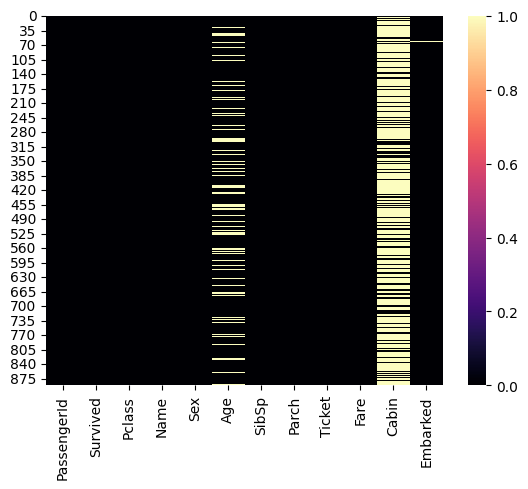

In [31]:
sns.heatmap(train.isnull() , cmap="magma")

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
train['Pclass']

,Pclass
0,3
1,1
2,3
3,1
4,3
...,...
886,2
887,1
888,3
889,1


In [34]:
train['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [35]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [38]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [45]:
cabin_list = [ "A" , "B" , "C" , "D" , "E" , "F" , "T" , "G" , "Unknown"]

In [40]:
def search_substring(big_string, substring_list):
  for substring in substring_list:
    if substring in big_string:
      return substring
  return substring_list[-1]


In [41]:
import re
text= "My name is satyam. "
match= re.search("satyam",text)
print(match.group())

satyam


In [42]:
def get_title(string):
  import re
  regex=re.compile(r'MR|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countess|Dona|Ms|Miss|Mile|Master' , re.IGNORECASE)
  results = regex.search(string)
  if results != None:
    return(results.group().lower())
  else:
    return(str(np.nan))

In [43]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [46]:
train['Deck']=train['Cabin'].map(lambda x:search_substring(str(x),cabin_list))
train.drop('Cabin',axis=1,inplace=True)
train['Title']=train['Name'].apply(get_title)
train['Title']=train['Title'].map(title_dictionary)

In [49]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [50]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [51]:
train.drop('Name',axis=1,inplace=True)

In [52]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [53]:
train.tail()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
886,887,0,2,male,27.0,0,0,211536,13.00,S,Unknown,Officer
887,888,1,1,female,19.0,0,0,112053,30.00,S,B,Miss
888,889,0,3,female,NaN,1,2,W./C. 6607,23.45,S,Unknown,Miss
889,890,1,1,male,26.0,0,0,111369,30.00,C,C,Mr
890,891,0,3,male,32.0,0,0,370376,7.75,Q,Unknown,Mr


In [54]:
train.drop('Ticket',axis=1,inplace=True)

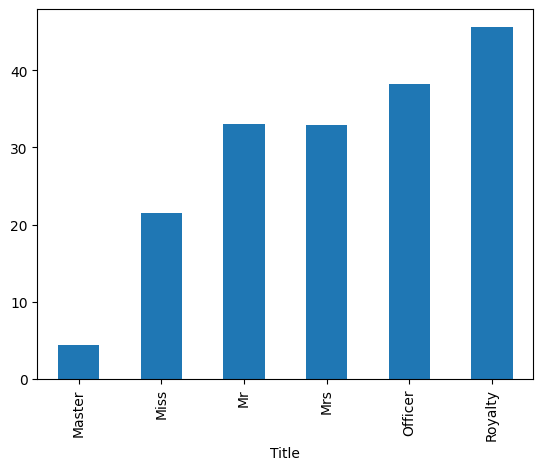

In [55]:
means_title=train.groupby('Title')['Age'].mean()
mk=train.groupby('Title')['Age'].mean().plot(kind='bar')

In [57]:
title_list=['Mr','Miss','Mrs','Master','Royalty','Officer']
def age_nan_replace(means,dframe,title_list):
  for title in title_list:
    temp=dframe['Title']==title
    dframe.loc[temp,'Age']=dframe.loc[temp,'Age'].fillna(means[title])
age_nan_replace(means_title,train,title_list)
age_nan_replace(means_title,train,title_list)

In [58]:
train['Family Size']=train['Parch']+train['SibSp']
train.drop('Parch',axis=1,inplace=True)
train.drop('SibSp',axis=1,inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,female,38.0,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,female,35.0,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,8.0500,S,Unknown,Mr,0
